In [50]:
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
## Load the dataset
data = pd.read_csv('//workspaces//group-project-team1//fourth_downs_2020_2021.csv')

/tmp/ipykernel_7062/3882954192.py:2: DtypeWarning: Columns (0: lateral_receiver_player_id, 1: lateral_receiver_player_name, 2: lateral_punt_returner_player_id, 3: lateral_punt_returner_player_name, 4: qb_hit_2_player_id, 5: qb_hit_2_player_name, 6: pass_defense_2_player_id, 7: pass_defense_2_player_name, 8: fumbled_2_player_id, 9: fumbled_2_player_name, 10: fumbled_2_team, 11: fumble_recovery_2_team, 12: fumble_recovery_2_player_id, 13: fumble_recovery_2_player_name, 14: half_sack_1_player_id, 15: half_sack_1_player_name, 16: half_sack_2_player_id, 17: half_sack_2_player_name, 18: safety_player_name, 19: safety_player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('//workspaces//group-project-team1//fourth_downs_2020_2021.csv')


In [52]:
data.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,197,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,SF,home,ARI,...,0,1,2.147877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,405,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,ARI,away,SF,...,0,1,0.106613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,569,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,ARI,away,SF,...,1,1,-0.233794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,675,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,SF,home,ARI,...,0,1,-4.547876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,854,2020_01_ARI_SF,2020091311,SF,ARI,REG,1,SF,home,ARI,...,0,1,0.133453,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
## Remove the 'play_id' column as it is not needed for correlation analysis
data = data.drop(columns=['play_id'])

In [54]:
## Remove any column that has "team" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'team' in col])

In [55]:
## Remove any column with "player" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'player' in col])

In [56]:
## Remove any column with "id" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'id' in col])

In [57]:
## Remove any column with "epa" or "wpa" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'epa' in col or 'wpa' in col])

In [58]:
## Remove any column with "fumble" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'fumble' in col])


In [59]:
data.shape

(8086, 193)

In [60]:
## Remove any column with "kickoff" or "punt" in its name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'kickoff' in col or 'punt' in col])

In [61]:
## Remove columns with 'jersey_number' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'jersey_number' in col])


In [63]:
## Remove 'game_date', 'name', 'jersey_number', 'fantasy', 'xyac_mean_yardage', 'xyac_median_yardage', 'xyac_success', 'xyac_fd', 'xpass' as they are not needed for correlation analysis
columns_to_drop = ['game_date', 'name', 'fantasy', 'xyac_mean_yardage', 'xyac_median_yardage', 'xyac_success', 'xyac_fd', 'xpass']
data = data.drop(columns=columns_to_drop)

In [64]:
## Drop passer, rusher, receiver, 'qb_kneel', 'qb_spike', 'yards_after_catch' 
columns_to_drop = [col for col in data.columns if 'passer' in col or 'rusher' in col or 'receiver' in col or 'qb_kneel' in col or 'qb_spike' in col or 'yards_after_catch' in col]
data = data.drop(columns=columns_to_drop) 

In [65]:
## Drop any columns with 'tackle' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'tackle' in col])

In [66]:
## Drop any column with 'drive' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'drive' in col])

In [70]:
## Remove columns with 'lateral' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'lateral' in col])

In [73]:
## Remove column with 'end' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'end' in col])

In [76]:
## Remove columns with 'extra_point' or 'two_point' in name as it is not needed for correlation analysis
data = data.drop(columns=[col for col in data.columns if 'extra_point' in col or 'two_point' in col])

In [79]:
## Remove columns with 'spread' or 'total_line' or 'vegas' or 'third_down' or 'first_down' in name
data = data.drop(columns=[col for col in data.columns if 'spread' in col or 'total_line' in col or 'vegas' in col or 'third_down' in col or 'first_down' in col])

In [82]:
## Remove play_clock and play_aborted and play_deleted
data = data.drop(columns=[col for col in data.columns if 'play_clock' in col or 'play_aborted' in col or 'play_deleted' in col])

In [67]:
## Drop any remaining non-numeric columns
data = data.select_dtypes(include=['number'])

In [83]:
data.shape

(8086, 84)

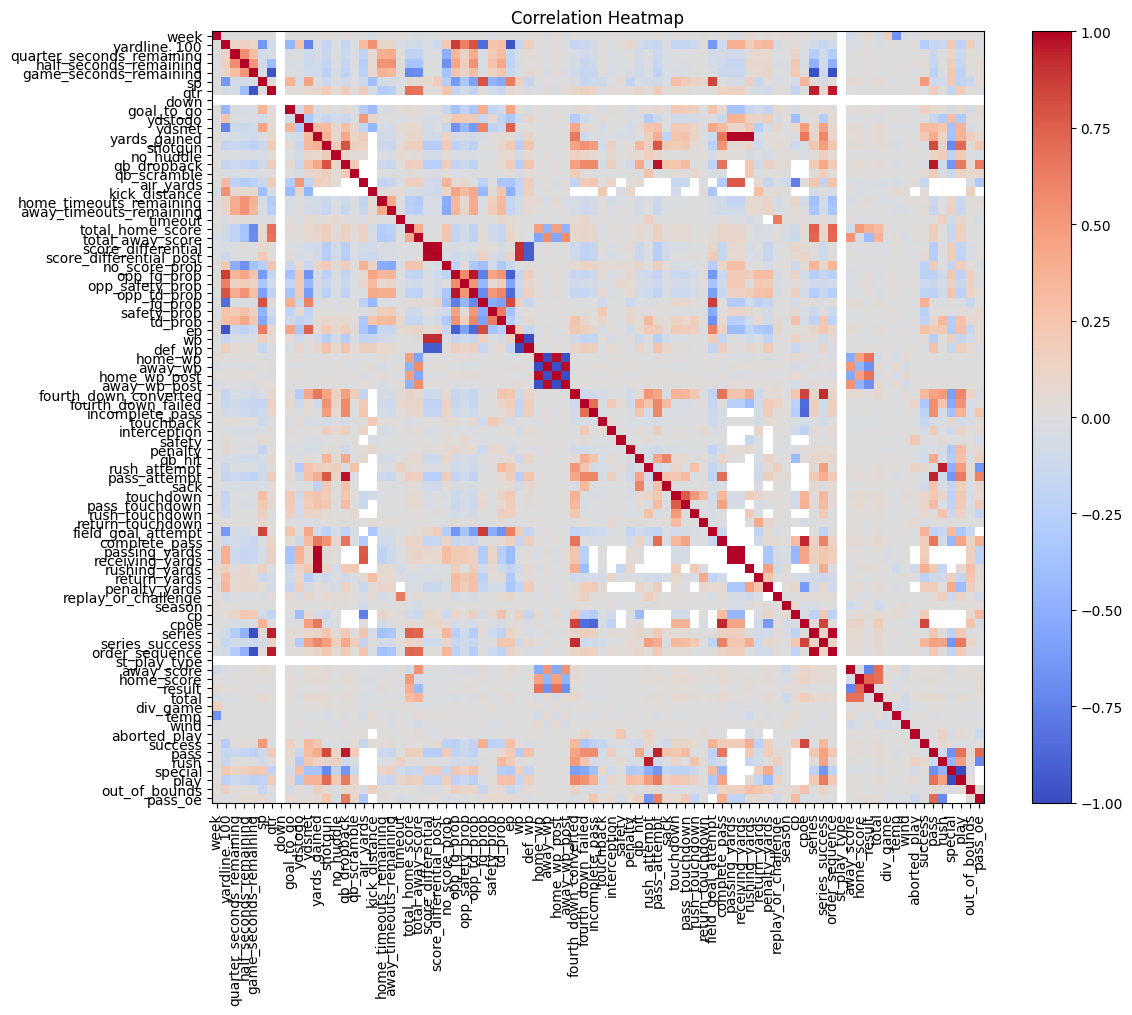

In [84]:
## Target variable = 'fourth_down_converted'
## Calculate the correlation matrix
## Drop non-numeric columns before calculating the correlation matrix
numeric_data = data.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr()
## Plot the correlation heatmap
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()